# VAE
変分オートエンコーダ

## import

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets
import torchvision.transforms.v2 as transforms_v2
from tqdm.auto import tqdm


## Use GPU if Available

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


## Model Definition

### Encoder
$q_\phi(z|x)$: 画像 $x$ を条件として，潜在変数 $z$ の確率分布（雲）を出力する関数（$\phi$ は重みパラメータ）．

In [4]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, hidden_dim)
        self.linear_mu = nn.Linear(hidden_dim, latent_dim)
        self.linear_logvar = nn.Linear(hidden_dim, latent_dim) # 「分散は正」という制約があるため一旦，分散の対数を出力させる．
    
    def forward(self, x):
        h = self.linear(x) # (32, 784) -> (32, 200)
        h = F.relu(h) # (32, 200)
        mu = self.linear_mu(h) # (32, 200) -> (32, 20)
        logvar = self.linear_logvar(h) # (32, 200) -> (32, 20)
        sigma = torch.exp(0.5 * logvar) # (32, 20)
        return mu, sigma # (32, 20), (32, 20)


### Decoder
$p_\theta(x|z)$: 潜在変数 $z$ を条件として，画像 $x$ を復元する関数（$\theta$ は重みパラメータ）．

In [5]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.linear1 = nn.Linear(latent_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = self.linear1(z) #.  (32, 20) -> (32, 200)
        h = F.relu(h) # (32, 200)
        h = self.linear2(h) # (32, 784)
        x_hat = F.sigmoid(h) # (32, 784)．MNISTが[0, 1]に正規化されているため，シグモイド関数を使う．
        return x_hat


### VAE

In [6]:
def reparameterize(mu, sigma):
    eps = torch.randn_like(sigma) # (32, 20)．標準正規分布（平均0，分散1）からサンプリングされたsigmaと同じサイズのテンソル
    z = mu + (eps * sigma) # (32, 20) = (32, 20) + ((32, 20) * (32, 20))
    return z # (32, 20)

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)
    
    def get_loss(self, x):
        mu, sigma = self.encoder(x) # (32, 20), (32, 20)
        z = reparameterize(mu, sigma) # (32, 20)
        x_hat = self.decoder(z)

        batch_size = x.size(0)
        L1 = F.mse_loss(x_hat, x, reduction='sum')
        L2 = - torch.sum(1 + torch.log(sigma ** 2) - mu ** 2 - sigma ** 2)
        return (L1 + L2) / batch_size


## Preparation

In [7]:
transform = transforms_v2.Compose([
    transforms_v2.ToImage(), # PIL -> Tensor形式
    transforms_v2.ToDtype(torch.float32, scale=True), # [0, 255] -> [0, 1]
    transforms_v2.Lambda(torch.flatten)
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
batch_size = 32
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

input_dim = 784 # x dimension
hidden_dim = 200 # neurons in hidden layers
latent_dim = 20 # z dimension
model = VAE(input_dim, hidden_dim, latent_dim).to(device)

lr = 3e-4
optimizer = optim.Adam(model.parameters(), lr=lr)

losses = []


100%|██████████| 9.91M/9.91M [00:00<00:00, 60.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.74MB/s]


## Training

In [8]:
num_epochs = 30

for epoch in tqdm(range(num_epochs), leave=True, desc='Epoch'):
    loss_sum = 0.0
    cnt = 0

    for x, label in tqdm(dataloader, leave=False, desc='Iteration'):
        x = x.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        loss = model.get_loss(x)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        cnt += 1

    loss_avg = loss_sum / cnt
    print(f"epoch: {epoch}/{num_epochs}, loss_avg: {loss_avg}")
    losses.append(loss_avg)


Epoch:   0%|          | 0/30 [00:00<?, ?it/s]

Iteration:   0%|          | 0/1875 [00:00<?, ?it/s]

epoch: 0/30, loss_avg: 53.87639934895833


Iteration:   0%|          | 0/1875 [00:00<?, ?it/s]

epoch: 1/30, loss_avg: 45.28397604573568


...

epoch: 27/30, loss_avg: 38.73375899861654


Iteration:   0%|          | 0/1875 [00:00<?, ?it/s]

epoch: 28/30, loss_avg: 38.765109238688154


Iteration:   0%|          | 0/1875 [00:00<?, ?it/s]

epoch: 29/30, loss_avg: 38.713608964029945


## Learning Curve

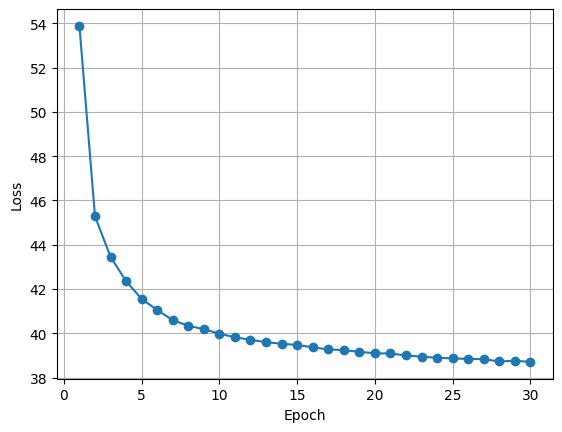

In [9]:
epochs = list(range(1, num_epochs + 1))
plt.plot(epochs, losses, marker='o', linestyle='-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()


## Generating New Images
**質問：生成時のサンプリングは、理論的に標準正規分布と決まっているのか？**

**結論：はい、理論的に「完全に」標準正規分布 $\mathcal{N}(0, 1)$ と決まっています。**

数学的に言うと、VAEは「潜在空間の事前分布（Prior） $p(z)$ は標準正規分布である」と人間が勝手に仮定（決め打ち）して設計されています。
- $p(z) = \mathcal{N}(z; 0, I)$ ： 理想の潜在空間（標準正規分布）
- $q_\phi(z|x)$ ： Encoderが画像から作った雲

学習中、Encoderは頑張って $q_\phi$ を $p(z)$ に近づけました。つまり、学習が終わったDecoder $p_\theta(x|z)$ は、「標準正規分布の範囲内（だいたい -3.0 〜 +3.0 の範囲）から来る点 $z$ の復元方法しか教わっていない」のです。

- 制約を破るとどうなるか？
    - 分散を大きくする（例: z = torch.randn(...) * 10）

        標準正規分布の範囲（雲の濃い部分）を突き抜けて、データが全く存在しない「宇宙の果ての隙間（外れ値）」をサンプリングしてしまいます。Decoderは「こんな遠くの座標、見たことない！」とパニックになり、無理やり知っている特徴を繋ぎ合わせようとして「お化け屋敷のような歪んだ画像」を出力します。

    - 平均を1e6に飛ばす（例: z = torch.randn(...) + 1e6）

        これはもう、学習した空間から完全に逸脱しています。Decoderを構成するニューラルネット（LinearやReLUなど）に想定外の巨大な数値が入力されると、活性化関数が飽和（限界値に張り付く）したりして、どのピクセルも同じような値を出力するようになります。結果として「数字ではない何か（均一なノイズやベタ塗り）」になります。

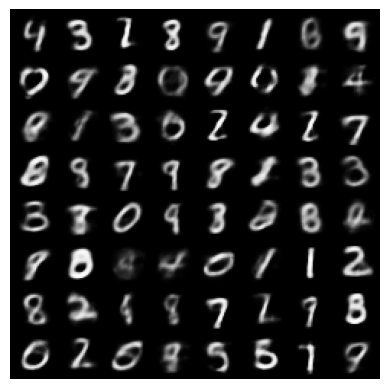

In [19]:
with torch.no_grad():
    sample_size = 64
    z = torch.randn(sample_size, latent_dim) * 1
    z = z.to(device)
    x = model.decoder(z)
    generated_images = x.view(sample_size, 1, 28, 28)

grid_img = torchvision.utils.make_grid(generated_images, nrow=8, padding=2, normalize=True)
grid_img = grid_img.cpu().detach()
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.show()


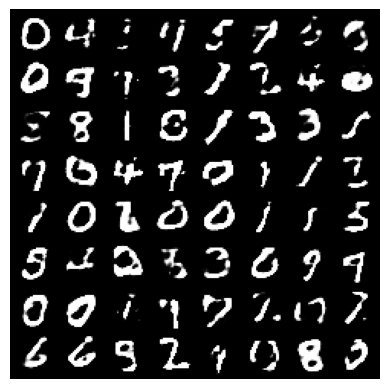

In [ ]:
"""
「分散を大きくする」
標準正規分布の範囲（雲の濃い部分）を突き抜けて、データが全く存在しない「宇宙の果ての隙間（外れ値）」をサンプリングしてしまいます。
Decoderは「こんな遠くの座標、見たことない！」とパニックになり、無理やり知っている特徴を繋ぎ合わせようとして「お化け屋敷のような歪んだ画像」を出力します。
"""
with torch.no_grad():
    sample_size = 64
    z = torch.randn(sample_size, latent_dim) * 10
    z = z.to(device)
    x = model.decoder(z)
    generated_images = x.view(sample_size, 1, 28, 28)

grid_img = torchvision.utils.make_grid(generated_images, nrow=8, padding=2, normalize=True)
grid_img = grid_img.cpu().detach()
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.show()


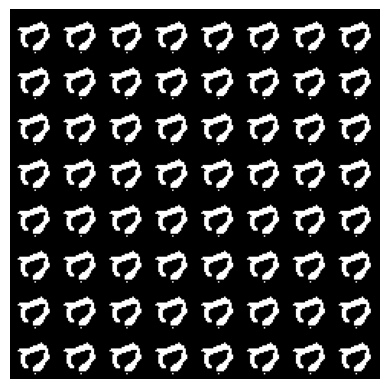

In [ ]:
"""
「平均を1e6に飛ばす」
これはもう、学習した空間から完全に逸脱しています。
Decoderを構成するニューラルネット（LinearやReLUなど）に想定外の巨大な数値が入力されると、
活性化関数が飽和（限界値に張り付く）したりして、どのピクセルも同じような値を出力するようになります。
結果として「数字ではない何か（均一なノイズやベタ塗り）」になります。
"""
with torch.no_grad():
    sample_size = 64
    z = torch.randn(sample_size, latent_dim) + 1e6
    z = z.to(device)
    x = model.decoder(z)
    generated_images = x.view(sample_size, 1, 28, 28)

grid_img = torchvision.utils.make_grid(generated_images, nrow=8, padding=2, normalize=True)
grid_img = grid_img.cpu().detach()
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.show()


## Morphing

In [23]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as IPythonImage

# ※ get_digit_mean_mu 関数は先ほどのものをそのまま使用します
def get_digit_mean_mu(model, dataloader, target_digit, device, max_samples=500):
    model.eval()
    mu_list = []
    with torch.no_grad():
        for x, label in dataloader:
            mask = (label == target_digit)
            if not mask.any(): continue
            x_filtered = x[mask].to(device)
            mu, _ = model.encoder(x_filtered)
            mu_list.append(mu.cpu())
            if sum([m.size(0) for m in mu_list]) >= max_samples: break
    all_mu = torch.cat(mu_list, dim=0)[:max_samples]
    return all_mu.mean(dim=0, keepdim=True)

# デバイス設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ---------------------------------------------------------
# 1. 0 から 9 までのすべての「本拠地（平均ベクトル）」をあらかじめ取得
# ---------------------------------------------------------
print("各数字の平均ベクトルを抽出中...")
digit_mus = {}
for digit in range(10):
    digit_mus[digit] = get_digit_mean_mu(model, dataloader, target_digit=digit, device=device).to(device)

# ---------------------------------------------------------
# 2. 巡回ルートの設定とマーチング
# ---------------------------------------------------------
# 0 -> 1 -> 2 -> ... -> 9 -> 0 と繋がるルート
route = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0]
steps_per_transition = 15  # 数字1つあたりの変化フレーム数（全体で15 * 10 = 150フレームになります）

pil_frames = []
model.eval()

# 各数字間の遷移を順番に処理
for i in range(len(route) - 1):
    start_digit = route[i]
    end_digit = route[i+1]
    
    mu_start = digit_mus[start_digit]
    mu_end = digit_mus[end_digit]
    
    print(f"マーチング中: {start_digit} -> {end_digit}")
    
    for step in range(steps_per_transition):
        # 【プロのハック】分母を (steps_per_transition - 1) ではなく、(steps_per_transition) にする
        # これにより、t=1.0（完全に次の数字になった瞬間）の手前で止める。
        # 完全に次の数字になったフレームは、次のループの「step=0 (t=0.0)」で生成されるため、重複が防げる。
        t = step / steps_per_transition
        
        # 線形補間
        z_interp = (1.0 - t) * mu_start + t * mu_end
        
        # デコード
        with torch.no_grad():
            x_hat = model.decoder(z_interp)
            frame = x_hat.view(28, 28)
            
        # 画像変換
        frame_np = frame.cpu().numpy()
        frame_uint8 = (frame_np * 255).astype(np.uint8)
        pil_img = Image.fromarray(frame_uint8)
        pil_frames.append(pil_img)

# ---------------------------------------------------------
# 3. GIFの保存と表示
# ---------------------------------------------------------
loop_gif_path = "vae_omni_loop.gif"

pil_frames[0].save(
    loop_gif_path,
    save_all=True,
    append_images=pil_frames[1:],
    duration=40,  # 1フレームあたり40ms (25fps) でサクサク動かす
    loop=0        # 無限ループ
)

print(f"\n完璧な無限ループGIFを保存しました: {loop_gif_path}")

# Jupyter上で表示
IPythonImage(filename=loop_gif_path)


各数字の平均ベクトルを抽出中...
マーチング中: 0 -> 1
マーチング中: 1 -> 2
マーチング中: 2 -> 3
マーチング中: 3 -> 4
マーチング中: 4 -> 5
マーチング中: 5 -> 6
マーチング中: 6 -> 7
マーチング中: 7 -> 8
マーチング中: 8 -> 9
マーチング中: 9 -> 0

完璧な無限ループGIFを保存しました: vae_omni_loop.gif
